# AI-Generated Image Detection

**CSYM015 Intelligent Systems | University of Northampton**

The rapid proliferation of text-to-image generative models including Stable Diffusion, Midjourney, and DALL·E has intensified the risk of synthetic media being used for misinformation, fraud, and erosion of public trust. This project designs, implements, and evaluates a binary classifier that distinguishes real photographs from AI-generated images by fusing three complementary feature streams namely spatial features from a pretrained EfficientNet-B3 backbone, frequency-domain representations derived from two-dimensional fast Fourier transform (FFT) and block-based discrete cosine transform (DCT) maps, and noise residual maps inspired by photographic sensor forensics. The training and primary evaluation phases use the CIFAKE dataset from kaggle. The official CIFAKE training folder contains 100,000 images; 80,000 were used for training and 20,000 for validation, with evaluation on the held-out 20,000-image test set. The proposed asymmetric focal loss prioritizes recall of fake images to reflect the societal cost of false negatives in misinformation contexts.

Following exploratory data analysis and a documented three-phase training protocol the fusion model achieves 98.6% accuracy, 99.3% recall (fake class), 97.9% precision, F1 = 0.986, and AUC-ROC = 0.999 on the held-out CIFAKE test set (n = 20,000). Robustness experiments on a 500-image stratified subset show that moderate JPEG compression and low-level Gaussian noise preserve performance above 92% F1, while heavy noise (σ = 0.10) degrades F1 to 0.821. Grad-CAM visualizations indicate that the spatial branch attends to local texture and structure. Further analysis confirms that performance does not generalize reliably to arbitrary out-of-distribution images, a limitation shared with much of the literature when training data are narrow in resolution and generator type. A Fast API microservice and Next.js web interface was used to demonstrate end-to-end deployment. The work aligns with UN Sustainable Development Goals 16 (peace, justice, and strong institutions) and 10 (reduced inequalities) by contributing technical capacity to combat synthetic media abuse.


| Section | Content |
|---------|---------|
| 1 | Setup & configuration |
| 2 | Data verification & **EDA** |
| 3 | Design rationale |
| 4 | Preprocessing & data loaders |
| 5 | Model, training, evaluation |
| 6 | Robustness & Grad-CAM |

In [1]:
from __future__ import annotations
import json, random, sys, time
from copy import deepcopy
from dataclasses import dataclass, field
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from PIL import Image
from scipy.fft import dctn
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_recall_fscore_support, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

def get_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")


PyTorch 2.12.0 | Device: mps


In [2]:
def resolve_project_root() -> Path:
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "ai_image_detection.ipynb").exists() or (base / "data" / "cifake" / "train").exists():
            return base
    return Path.cwd()

@dataclass
class Config:
    project_root: Path = field(default_factory=resolve_project_root)
    img_size: int = 224
    imagenet_mean: tuple = (0.485, 0.456, 0.406)
    imagenet_std: tuple = (0.229, 0.224, 0.225)
    batch_size: int = 32
    num_workers: int = 0
    epochs: int = 30
    early_stop_patience: int = 5
    lr_backbone: float = 1e-4
    lr_head: float = 1e-3
    weight_decay: float = 1e-4
    val_split: float = 0.2
    focal_alpha: float = 0.75
    focal_gamma: float = 2.0
    class_names: tuple = ("REAL", "FAKE")
    noise_sigma: float = 1.5
    dct_block: int = 8

    def __post_init__(self):
        self.data_dir = self.project_root / "data"
        self.cifake_dir = self.data_dir / "cifake"
        self.models_dir = self.project_root / "models"
        self.outputs_dir = self.project_root / "outputs"
        for p in (self.data_dir, self.cifake_dir, self.models_dir, self.outputs_dir):
            p.mkdir(parents=True, exist_ok=True)

cfg = Config()
CKPT_PATH = cfg.models_dir / "fusion_detector_best.pt"
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
print(f"Project: {cfg.project_root.resolve()}")
print(f"Checkpoint: {CKPT_PATH} (exists={CKPT_PATH.exists()})")


Project: /Users/admin/Documents/Intelligent Systems/Project 2
Checkpoint: /Users/admin/Documents/Intelligent Systems/Project 2/models/fusion_detector_best.pt (exists=True)


## 1. Dataset verification (CIFAKE)

Expected: `data/cifake/train/{REAL,FAKE}`, `data/cifake/test/{REAL,FAKE}` — 100k train, 20k test.

In [3]:
def count_split(root: Path, labels) -> dict:
    out = {}
    for label in labels:
        for alt in (label, label.lower()):
            d = root / alt
            if d.exists():
                out[label] = len([f for f in d.iterdir() if f.suffix.lower() in IMG_EXTS])
                break
        else:
            out[label] = 0
    return out

counts = {"train": count_split(cfg.cifake_dir / "train", cfg.class_names),
          "test": count_split(cfg.cifake_dir / "test", cfg.class_names)}
print(json.dumps(counts, indent=2))
assert counts["train"]["REAL"] > 0, "Place CIFAKE under data/cifake/"


{
  "train": {
    "REAL": 50000,
    "FAKE": 50000
  },
  "test": {
    "REAL": 10000,
    "FAKE": 10000
  }
}


## 2. Exploratory data analysis (EDA)

Analysis **before training**: class balance, native resolution, and visual samples.  
CIFAKE uses 32×32 images upscaled to 224×224 in preprocessing

,split,class,count
0,train,REAL,50000
1,train,FAKE,50000
2,test,REAL,10000
3,test,FAKE,10000


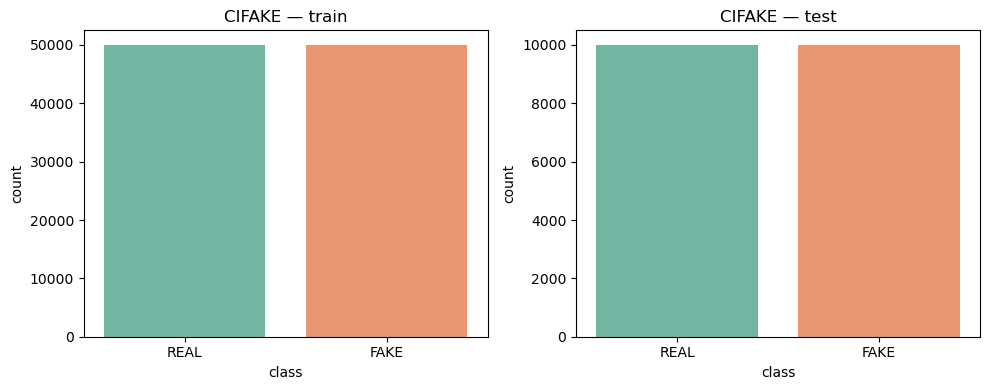

In [4]:
def count_images_by_class(root: Path, class_names) -> pd.DataFrame:
    rows = []
    for label in class_names:
        for alt in (label, label.lower()):
            d = root / alt
            if d.exists():
                n = len([f for f in d.iterdir() if f.suffix.lower() in IMG_EXTS])
                rows.append({"split": root.name, "class": label, "count": n})
                break
    return pd.DataFrame(rows)

frames = [count_images_by_class(cfg.cifake_dir / s, cfg.class_names) for s in ("train", "test")]
eda_df = pd.concat(frames, ignore_index=True)
display(eda_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, split in enumerate(eda_df["split"].unique()):
    sub = eda_df[eda_df["split"] == split]
    sns.barplot(data=sub, x="class", y="count", hue="class", ax=axes[i], palette="Set2", legend=False)
    axes[i].set_title(f"CIFAKE — {split}")
plt.tight_layout()
plt.savefig(cfg.outputs_dir / "eda_class_balance.png", dpi=120)
plt.show()


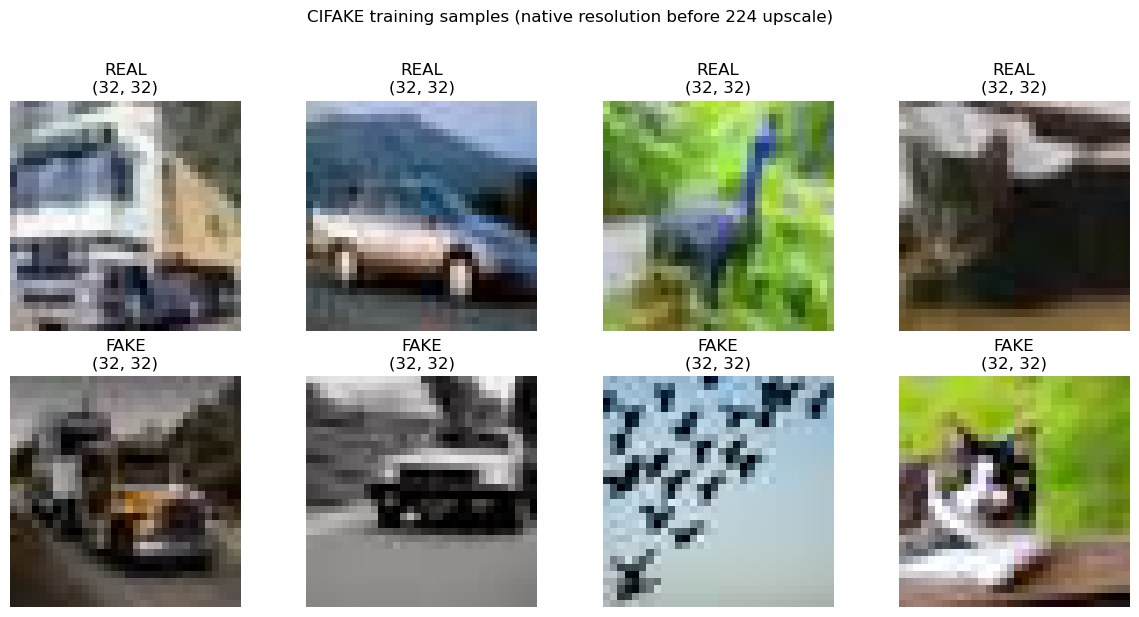

In [5]:
def sample_paths(root, labels, n=4):
    out = []
    for label in labels:
        for alt in (label, label.lower()):
            d = root / alt
            if not d.exists(): continue
            files = sorted([f for f in d.iterdir() if f.suffix.lower() in {".jpg",".jpeg",".png"}])[:n]
            out.extend((f, label) for f in files)
            break
    return out

train_root = cfg.cifake_dir / "train"
real_s = [(p,l) for p,l in sample_paths(train_root, cfg.class_names, 4) if l=="REAL"][:4]
fake_s = [(p,l) for p,l in sample_paths(train_root, cfg.class_names, 4) if l=="FAKE"][:4]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for col, (path, label) in enumerate(real_s):
    axes[0,col].imshow(Image.open(path).convert("RGB")); axes[0,col].set_title(f"{label}\n{Image.open(path).size}"); axes[0,col].axis("off")
for col, (path, label) in enumerate(fake_s):
    axes[1,col].imshow(Image.open(path).convert("RGB")); axes[1,col].set_title(f"{label}\n{Image.open(path).size}"); axes[1,col].axis("off")
fig.suptitle("CIFAKE training samples (native resolution before 224 upscale)", y=1.02)
plt.tight_layout()
plt.savefig(cfg.outputs_dir / "eda_samples_train.png", dpi=120, bbox_inches="tight")
plt.show()


      width         height        
       mean min max   mean min max
class                             
FAKE   32.0  32  32   32.0  32  32
REAL   32.0  32  32   32.0  32  32


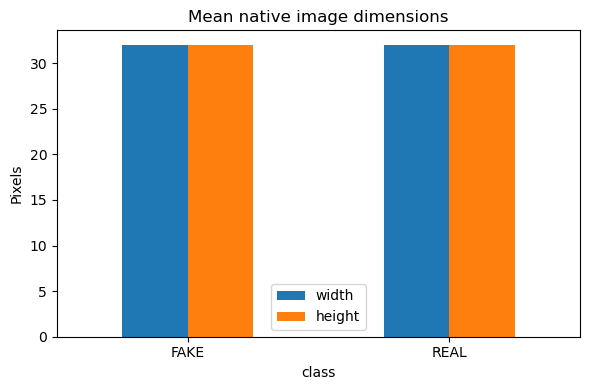

In [6]:
# Native resolution statistics
widths, heights, labels = [], [], []
for label in cfg.class_names:
    d = train_root / label
    if not d.exists(): d = train_root / label.lower()
    for f in list(d.iterdir())[:2500]:
        if f.suffix.lower() not in {".jpg",".jpeg",".png"}: continue
        w, h = Image.open(f).size
        widths.append(w); heights.append(h); labels.append(label)
res_df = pd.DataFrame({"width": widths, "height": heights, "class": labels})
print(res_df.groupby("class")[["width","height"]].agg(["mean","min","max"]))
res_df.groupby("class")[["width","height"]].mean().plot(kind="bar", figsize=(6,4), rot=0)
plt.ylabel("Pixels"); plt.title("Mean native image dimensions"); plt.tight_layout()
plt.savefig(cfg.outputs_dir / "eda_resolution.png", dpi=120)
plt.show()


## 3. Design rationale — why this approach?

| Alternative | Limitation | My Choice |
|-------------|------------|------------|
| Metadata / watermarks only | Easily removed; not always present | **Pixel-based forensic CNN** |
| Single RGB CNN (ResNet) | Misses spectral & sensor cues | **EfficientNet-B3 + fusion** |
| Frequency-only | Weak on spatial semantics | **FFT + DCT branch** |
| RGB-only deepfake detectors | Poor cross-generator generalisation (Wang et al., 2020) | **+ noise residual branch** |
| Attention fusion at this scale | Over-engineered | **Concatenation + MLP** (interpretable) |
| Standard cross-entropy | Treats FN and FP equally | **Asymmetric focal loss** (prioritise catching fakes) |



## 4. Preprocessing & data loaders

In [7]:
def get_geometric_transforms(cfg, train=True):
    size = cfg.img_size
    bicubic = transforms.InterpolationMode.BICUBIC
    if train:
        return transforms.Compose([
            transforms.Resize((size, size), interpolation=bicubic),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(10),
            transforms.RandomCrop(size, padding=16, padding_mode="reflect"),
        ])
    return transforms.Compose([transforms.Resize((size, size), interpolation=bicubic)])

def get_spatial_head_transforms(cfg, train=True):
    norm = transforms.Normalize(mean=cfg.imagenet_mean, std=cfg.imagenet_std)
    if train:
        return transforms.Compose([
            transforms.ColorJitter(0.2, 0.2, 0.2), transforms.ToTensor(), norm])
    return transforms.Compose([transforms.ToTensor(), norm])

def rgb_to_gray(rgb):
    return (0.299*rgb[...,0] + 0.587*rgb[...,1] + 0.114*rgb[...,2]).astype(np.float32)

def _minmax(a):
    return ((a - a.min()) / (a.max() - a.min() + 1e-8)).astype(np.float32)

def compute_fft_map(gray):
    m = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(gray))))
    return _minmax(m)

def compute_dct_map(gray, block=8):
    h, w = gray.shape; bh, bw = h//block, w//block
    grid = np.zeros((bh, bw), np.float32)
    for bi in range(bh):
        for bj in range(bw):
            b = gray[bi*block:(bi+1)*block, bj*block:(bj+1)*block]
            c = dctn(b, norm="ortho")
            grid[bi,bj] = np.mean(np.abs(c[1:,1:]))
    full = np.repeat(np.repeat(grid, block, 0), block, 1)[:h,:w]
    return _minmax(full)

def compute_noise_residual(rgb, sigma=1.5):
    blur = cv2.GaussianBlur(rgb, (0,0), sigmaX=sigma)
    r = rgb.astype(np.float32) - blur.astype(np.float32)
    for c in range(3):
        r[...,c] /= (np.max(np.abs(r[...,c])) + 1e-8)
    return r.astype(np.float32)

def build_frequency_tensor(rgb):
    g = rgb_to_gray(rgb)
    return torch.from_numpy(np.stack([compute_fft_map(g), compute_dct_map(g, cfg.dct_block)], 0))

def build_noise_tensor(rgb):
    return torch.from_numpy(compute_noise_residual(rgb, cfg.noise_sigma).transpose(2,0,1).copy())

def collect_samples(root, class_names):
    samples = []
    for idx, label in enumerate(class_names):
        for alt in (label, label.lower(), str(idx)):
            d = root / alt
            if d.exists():
                samples.extend((f, idx) for f in d.iterdir() if f.suffix.lower() in IMG_EXTS)
                break
    return samples

class CIFAKEDataset(Dataset):
    def __init__(self, samples, cfg, train=True):
        self.samples, self.cfg, self.train = samples, cfg, train
        self.geom = get_geometric_transforms(cfg, train)
        self.spatial_head = get_spatial_head_transforms(cfg, train)

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        path, label = self.samples[i]
        img = Image.open(path).convert("RGB")
        geom = self.geom(img)
        spatial = self.spatial_head(geom)
        rgb = np.asarray(geom, dtype=np.float32) / 255.0
        return {"spatial": spatial, "frequency": build_frequency_tensor(rgb),
                "noise": build_noise_tensor(rgb), "label": label}

train_all = collect_samples(cfg.cifake_dir / "train", cfg.class_names)
test_samples = collect_samples(cfg.cifake_dir / "test", cfg.class_names)
paths, labels = zip(*train_all)
tr_p, va_p, tr_l, va_l = train_test_split(paths, labels, test_size=cfg.val_split, stratify=labels, random_state=SEED)
train_samples = list(zip(tr_p, tr_l))
val_samples = list(zip(va_p, va_l))

pin = DEVICE.type == "cuda"
train_loader = DataLoader(CIFAKEDataset(train_samples, cfg, True), batch_size=cfg.batch_size, shuffle=True, num_workers=0, pin_memory=pin, drop_last=True)
val_loader = DataLoader(CIFAKEDataset(val_samples, cfg, False), batch_size=cfg.batch_size, shuffle=False, num_workers=0, pin_memory=pin)
test_loader = DataLoader(CIFAKEDataset(test_samples, cfg, False), batch_size=cfg.batch_size, shuffle=False, num_workers=0, pin_memory=pin)
print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")


Train: 80000 | Val: 20000 | Test: 20000


## 5. Model architecture

In [8]:
SPATIAL_DIM, FREQ_DIM, NOISE_DIM = 1536, 256, 128

class SpatialBranch(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        w = EfficientNet_B3_Weights.IMAGENET1K_V1 if pretrained else None
        bb = efficientnet_b3(weights=w)
        self.features, self.avgpool = bb.features, bb.avgpool
    def forward(self, x):
        return torch.flatten(self.avgpool(self.features(x)), 1)
    def freeze_backbone(self):
        for p in self.features.parameters(): p.requires_grad = False
    def unfreeze_all(self):
        for p in self.features.parameters(): p.requires_grad = True
    def unfreeze_last_blocks(self, n=2):
        self.freeze_backbone()
        for b in list(self.features.children())[-n:]:
            for p in b.parameters(): p.requires_grad = True

class FrequencyBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(2,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1))
        self.proj = nn.Linear(128, FREQ_DIM)
    def forward(self, x):
        return self.proj(torch.flatten(self.enc(x), 1))

class NoiseBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.AdaptiveAvgPool2d(1))
        self.proj = nn.Linear(64, NOISE_DIM)
    def forward(self, x):
        return self.proj(torch.flatten(self.enc(x), 1))

class FusionHead(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.BatchNorm1d(512), nn.ReLU(True), nn.Dropout(0.4),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(128, 2))
    def forward(self, x): return self.net(x)

class FusionDetector(nn.Module):
    def __init__(self, use_spatial=True, use_frequency=True, use_noise=True, pretrained_spatial=True):
        super().__init__()
        self.spatial = SpatialBranch(pretrained_spatial) if use_spatial else None
        self.frequency = FrequencyBranch() if use_frequency else None
        self.noise = NoiseBranch() if use_noise else None
        dim = sum([use_spatial and SPATIAL_DIM, use_frequency and FREQ_DIM, use_noise and NOISE_DIM])
        self.fusion = FusionHead(dim)
    def forward(self, spatial, frequency, noise):
        feats = []
        if self.spatial: feats.append(self.spatial(spatial))
        if self.frequency: feats.append(self.frequency(frequency))
        if self.noise: feats.append(self.noise(noise))
        fused = torch.cat(feats, 1)
        return {"logits": self.fusion(fused)}
    def forward_batch(self, batch):
        d = next(self.parameters()).device
        return self.forward(batch["spatial"].to(d), batch["frequency"].to(d), batch["noise"].to(d))


## 6. Loss, training, and checkpoint loading

In [9]:
class AsymmetricFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__(); self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        a = torch.where(targets==1, self.alpha, 1-self.alpha)
        return (a * ((1-pt)**self.gamma) * ce).mean()

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0): super().__init__(); self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        return (((1-pt)**self.gamma) * ce).mean()

def build_optimizer(model, cfg):
    backbone, head = [], []
    if model.spatial:
        backbone += [p for p in model.spatial.features.parameters() if p.requires_grad]
        backbone += [p for p in model.spatial.avgpool.parameters() if p.requires_grad]
    for m in (model.frequency, model.noise, model.fusion):
        if m: head += [p for p in m.parameters() if p.requires_grad]
    groups = []
    if backbone: groups.append({"params": backbone, "lr": cfg.lr_backbone})
    if head: groups.append({"params": head, "lr": cfg.lr_head})
    return torch.optim.AdamW(groups, weight_decay=cfg.weight_decay)

@torch.no_grad()
def evaluate_loader(model, loader, criterion, device):
    model.eval()
    yt, yp, yprob = [], [], []
    loss_sum, n = 0.0, 0
    for batch in tqdm(loader, desc="eval", leave=False):
        labels = batch["label"].to(device)
        out = model.forward_batch(batch)
        loss_sum += criterion(out["logits"], labels).item(); n += 1
        prob = F.softmax(out["logits"], 1)
        pred = out["logits"].argmax(1)
        yt.extend(labels.cpu().tolist()); yp.extend(pred.cpu().tolist())
        yprob.extend(prob[:,1].cpu().tolist())
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average="binary", pos_label=1, zero_division=0)
    return {"loss": loss_sum/max(n,1), "accuracy": accuracy_score(yt,yp), "precision": float(p),
            "recall": float(r), "f1": float(f1), "auc": float(roc_auc_score(yt,yprob)) if len(set(yt))>1 else 0,
            "y_true": yt, "y_pred": yp}

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, n = 0.0, 0
    for batch in tqdm(loader, desc="train", leave=False):
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        loss = criterion(model.forward_batch(batch)["logits"], labels)
        loss.backward(); optimizer.step()
        loss_sum += loss.item(); n += 1
    return loss_sum / max(n, 1)

def train_three_phase(model, train_loader, val_loader, cfg, device):
    criterion = AsymmetricFocalLoss(cfg.focal_alpha, cfg.focal_gamma)
    phases = [("frozen_backbone", 5), ("partial_unfreeze", 10), ("full_finetune", max(cfg.epochs-15, 5))]
    best_state = deepcopy(model.state_dict())
    best_f1, patience, global_epoch = 0.0, 0, 0
    history = {"train": [], "val": []}
    setup = {"frozen_backbone": lambda m: m.spatial.freeze_backbone() if m.spatial else None,
             "partial_unfreeze": lambda m: m.spatial.unfreeze_last_blocks(2) if m.spatial else None,
             "full_finetune": lambda m: m.spatial.unfreeze_all() if m.spatial else None}
    for phase_name, n_epochs in phases:
        if model.spatial and phase_name in setup: setup[phase_name](model)
        opt = build_optimizer(model, cfg)
        sched = CosineAnnealingWarmRestarts(opt, T_0=5, T_mult=2)
        print(f"\n=== {phase_name} ({n_epochs} epochs) ===")
        for _ in range(n_epochs):
            global_epoch += 1
            tl = train_epoch(model, train_loader, criterion, opt, device)
            vm = evaluate_loader(model, val_loader, criterion, device)
            sched.step()
            history["train"].append({"epoch": global_epoch, "phase": phase_name, **{k:vm[k] for k in ["loss","accuracy","f1"]}})
            history["val"].append({"epoch": global_epoch, "phase": phase_name, **vm})
            if vm["f1"] > best_f1:
                best_f1, patience = vm["f1"], 0
                best_state = deepcopy(model.state_dict())
                torch.save({"model_state_dict": best_state, "ablation": "A+B+C", "loss": "asym_focal",
                            "best_f1": best_f1, "class_names": cfg.class_names}, CKPT_PATH)
            else:
                patience += 1
            print(f"Epoch {global_epoch}: train_loss={tl:.4f} val_f1={vm['f1']:.3f} val_recall={vm['recall']:.3f} *" if vm['f1']==best_f1 else f"Epoch {global_epoch}: train_loss={tl:.4f} val_f1={vm['f1']:.3f} val_recall={vm['recall']:.3f}")
            if patience >= cfg.early_stop_patience:
                print(f"Early stopping at epoch {global_epoch}"); break
        if patience >= cfg.early_stop_patience: break
    model.load_state_dict(best_state)
    return model, history

def load_checkpoint(path, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model = FusionDetector(pretrained_spatial=False)
    model.load_state_dict(ckpt["model_state_dict"])
    return model.to(device).eval(), ckpt


In [10]:
if CKPT_PATH.exists():
    print(f"Loading checkpoint: {CKPT_PATH}")
    model, ckpt_meta = load_checkpoint(CKPT_PATH, DEVICE)
    history = None
    if isinstance(ckpt_meta, dict):
        print(f"  best_f1={ckpt_meta.get('best_f1', '?')}  ablation={ckpt_meta.get('ablation', '?')}")
else:
    print("No checkpoint found — starting full training (3-phase, asymmetric focal loss).")
    model = FusionDetector(pretrained_spatial=True).to(DEVICE)
    model, history = train_three_phase(model, train_loader, val_loader, cfg, DEVICE)
    print(f"Saved best model to {CKPT_PATH}")

if history:
    pd.DataFrame(history["val"]).plot(x="epoch", y="f1", figsize=(8,3)); plt.title("Validation F1"); plt.tight_layout(); plt.show()


Loading checkpoint: /Users/admin/Documents/Intelligent Systems/Project 2/models/fusion_detector_best.pt
  best_f1=0.9863095238095239  ablation=A+B+C


## 7. Test-set evaluation (held-out 20,000 images)

eval:   0%|          | 0/625 [00:00<?, ?it/s]

=== CIFAKE TEST RESULTS ===
  accuracy: 0.9859
  precision: 0.9791
  recall: 0.9931
  f1: 0.9860
  auc: 0.9991


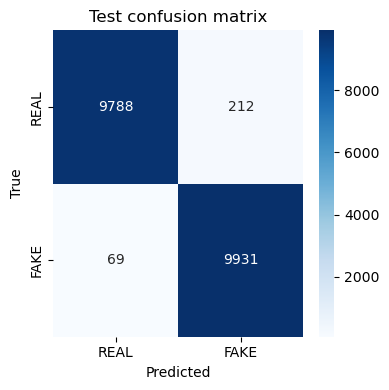

In [11]:
criterion = AsymmetricFocalLoss(cfg.focal_alpha, cfg.focal_gamma)
test_metrics = evaluate_loader(model, test_loader, criterion, DEVICE)
print("=== CIFAKE TEST RESULTS ===")
for k in ["accuracy","precision","recall","f1","auc"]:
    print(f"  {k}: {test_metrics[k]:.4f}")
(cfg.outputs_dir / "test_metrics.json").write_text(json.dumps({k: test_metrics[k] for k in ["accuracy","precision","recall","f1","auc","loss"]}, indent=2))

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"], labels=[0,1])
fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=cfg.class_names, yticklabels=cfg.class_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Test confusion matrix")
plt.tight_layout(); plt.savefig(cfg.outputs_dir / "test_confusion_matrix.png", dpi=120); plt.show()


## 8.5 Baseline and ablation experiments

Compares **logistic regression** (handcrafted forensic features) and **branch ablations** (5-epoch frozen-backbone quick train per config on 4k train / 4k test subset). Full A+B+C uses the main checkpoint on the full 20k test set.



In [13]:
# Baseline + ablation
RUN_ABLATION = False          # True = train all branch variants
ABLATION_USE_FULL_DATA = True   # True = all train_samples + all test_samples (20k test)
ABLATION_EPOCHS = 5             
import subprocess, sys
subprocess.run([sys.executable, str(cfg.project_root / "scripts/run_lr_baseline.py")], check=True)
display(pd.DataFrame([json.loads((cfg.outputs_dir / "baseline_results.json").read_text())]))
def stratified_subsample(samples, n=None, seed=SEED):
     if n is None or n >= len(samples):
        return list(samples)
    by_label = {}
    for path, label in samples:
        by_label.setdefault(label, []).append((path, label))
    per = n // len(by_label)
    rng = random.Random(seed)
    out = []
    for label in sorted(by_label):
        pool = by_label[label]
        rng.shuffle(pool)
        out.extend(pool[:per])
    rng.shuffle(out)
    return out

ABLATION_CONFIGS = [
    ("A spatial only", True, False, False),
    ("B frequency only", False, True, False),
    ("C noise only", False, False, True),
    ("A+B", True, True, False),
    ("A+C", True, False, True),
    ("B+C", False, True, True),
]

def quick_train_eval(us, uf, un, name, epochs=ABLATION_EPOCHS):
    from torch.utils.data import Subset
    if ABLATION_USE_FULL_DATA:
        tr_idx = list(range(len(train_samples)))
        te = list(test_samples)
    else:
        from sklearn.model_selection import train_test_split
        idx = list(range(len(train_samples)))
        tr_idx, _ = train_test_split(idx, test_size=0.5,
            stratify=[train_samples[i][1] for i in idx], random_state=SEED)
        tr_idx = tr_idx[:2000]
        te = stratified_subsample(test_samples, 2000)
    print(f"\n=== {name} | train={len(tr_idx)} test={len(te)} epochs={epochs} ===")
    m = FusionDetector(us, uf, un, pretrained_spatial=True).to(DEVICE)
    if m.spatial:
        m.spatial.freeze_backbone()
    opt = build_optimizer(m, cfg)
    crit = AsymmetricFocalLoss(cfg.focal_alpha, cfg.focal_gamma)
    dl = DataLoader(Subset(CIFAKEDataset(train_samples, cfg, True), tr_idx),
                    batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    for ep in range(epochs):
        tl = train_epoch(m, dl, crit, opt, DEVICE)
        print(f"  epoch {ep+1}/{epochs} train_loss={tl:.4f}")
    te_loader = DataLoader(CIFAKEDataset(te, cfg, False), batch_size=cfg.batch_size,
                           shuffle=False, num_workers=0)
    r = evaluate_loader(m, te_loader, crit, DEVICE)
    return {"model": name, "train_n": len(tr_idx), "test_n": len(te),
            "accuracy": r["accuracy"], "precision": r["precision"],
            "recall": r["recall"], "f1": r["f1"], "auc": r["auc"]}

rows = []
if RUN_ABLATION:
    for name, us, uf, un in ABLATION_CONFIGS:
        rows.append(quick_train_eval(us, uf, un, name))
else:
    print("Set RUN_ABLATION=True to train branch ablations.")

full = json.loads((cfg.outputs_dir / "test_metrics.json").read_text())
rows.append({"model": "A+B+C full (20k test)", "train_n": len(train_samples), "test_n": 20000,
             **{k: full[k] for k in ["accuracy","precision","recall","f1","auc"]}})

ablation_df = pd.DataFrame(rows)
display(ablation_df)
ablation_df.to_csv(cfg.outputs_dir / "ablation_results.csv", index=False)
ablation_df.to_json(cfg.outputs_dir / "ablation_results.json", orient="records", indent=2)

Extracting features (full dataset unless MAX_PER_CLASS_* set in script)...


test: 100%|██████████| 20000/20000 [01:24<00:00, 237.58it/s]


{
  "model": "Logistic Regression (24 handcrafted forensic features)",
  "train_n": 100000,
  "test_n": 20000,
  "accuracy": 0.77035,
  "precision": 0.7779948586118252,
  "recall": 0.7566,
  "f1": 0.767148288973384,
  "auc": 0.85109268,
  "train_seconds": 524.2,
  "note": "Full CIFAKE train/test unless MAX_PER_CLASS_* capped in script"
}
Saved /Users/admin/Documents/Intelligent Systems/Project 2/outputs/baseline_results.json


,model,train_n,test_n,accuracy,precision,recall,f1,auc,train_seconds,note
0,Logistic Regression (24 handcrafted forensic f...,100000,20000,0.77035,0.777995,0.7566,0.767148,0.851093,524.2,Full CIFAKE train/test unless MAX_PER_CLASS_* ...



=== A spatial only | train=80000 test=20000 epochs=5 ===


...

  epoch 4/5 train_loss=0.0339


train:   0%|          | 0/2500 [00:00<?, ?it/s]

  epoch 5/5 train_loss=0.0325


eval:   0%|          | 0/625 [00:00<?, ?it/s]

,model,train_n,test_n,accuracy,precision,recall,f1,auc
0,A spatial only,80000,20000,0.74935,0.669776,0.9837,0.796938,0.937777
1,B frequency only,80000,20000,0.51255,0.506436,0.9875,0.669514,0.802949
2,C noise only,80000,20000,0.60890,0.561214,0.9984,0.718532,0.906724
3,A+B,80000,20000,0.77715,0.696407,0.9827,0.815147,0.951023
4,A+C,80000,20000,0.78970,0.707849,0.9866,0.824296,0.958923
5,B+C,80000,20000,0.62730,0.573338,0.9952,0.727539,0.892476
6,A+B+C full (20k test),80000,20000,0.98595,0.979099,0.9931,0.986050,0.999064


## 8. Robustness & Grad-CAM

jpeg@90:   0%|          | 0/500 [00:00<?, ?it/s]

jpeg@70:   0%|          | 0/500 [00:00<?, ?it/s]

jpeg@50:   0%|          | 0/500 [00:00<?, ?it/s]

jpeg@30:   0%|          | 0/500 [00:00<?, ?it/s]

noise@0.02:   0%|          | 0/500 [00:00<?, ?it/s]

noise@0.05:   0%|          | 0/500 [00:00<?, ?it/s]

noise@0.1:   0%|          | 0/500 [00:00<?, ?it/s]

,perturbation,level,accuracy,f1,recall
0,jpeg,90.00,0.984,0.982906,0.991379
1,jpeg,70.00,0.982,0.980892,0.995690
2,jpeg,50.00,0.972,0.970085,0.978448
3,jpeg,30.00,0.956,0.951754,0.935345
4,noise,0.02,0.962,0.960334,0.991379
5,noise,0.05,0.920,0.918367,0.969828
6,noise,0.10,0.836,0.820961,0.810345


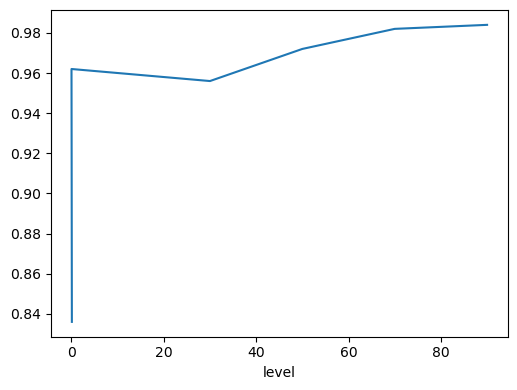

In [14]:
# Robustness (500-image random test subset)
from sklearn.model_selection import train_test_split as tts
rng = random.Random(SEED)
pool = list(test_loader.dataset.samples)
sub = rng.sample(pool, min(500, len(pool)))

def pil_to_batch(pil):
    geom = get_geometric_transforms(cfg, False)(pil.convert("RGB"))
    rgb = np.asarray(geom, np.float32)/255.0
    return {"spatial": get_spatial_head_transforms(cfg, False)(geom).unsqueeze(0),
            "frequency": build_frequency_tensor(rgb).unsqueeze(0),
            "noise": build_noise_tensor(rgb).unsqueeze(0)}

@torch.no_grad()
def predict_pil(pil):
    b = pil_to_batch(pil)
    d = next(model.parameters()).device
    out = model.forward_batch({k: v.to(d) for k,v in b.items()})
    p = F.softmax(out["logits"],1)[0]
    return int(p.argmax()), float(p[1].item())

import io
def jpeg(pil, q):
    buf = io.BytesIO(); pil.save(buf, format="JPEG", quality=int(q)); buf.seek(0)
    return Image.open(buf).convert("RGB")

rob_rows = []
grid = {"jpeg":[90,70,50,30], "noise":[0.02,0.05,0.1]}
for kind, levels in grid.items():
    for lv in levels:
        yt, yp = [], []
        for path, label in tqdm(sub, leave=False, desc=f"{kind}@{lv}"):
            pil = Image.open(path).convert("RGB")
            if kind=="jpeg": pil = jpeg(pil, lv)
            elif kind=="noise":
                a = np.array(pil, np.float32)/255
                a = np.clip(a + np.random.normal(0, lv, a.shape), 0, 1)
                pil = Image.fromarray((a*255).astype(np.uint8))
            pred, _ = predict_pil(pil)
            yt.append(label); yp.append(pred)
        p,r,f1,_ = precision_recall_fscore_support(yt,yp,average="binary",pos_label=1,zero_division=0)
        rob_rows.append({"perturbation":kind,"level":lv,"accuracy":accuracy_score(yt,yp),"f1":float(f1),"recall":float(r)})
rob_df = pd.DataFrame(rob_rows); display(rob_df)
rob_df.to_csv(cfg.outputs_dir / "exp4_robustness.csv", index=False)
rob_df.plot(x="level", y="accuracy", kind="line", subplots=True, layout=(1,2), figsize=(10,4), legend=False)
plt.tight_layout(); plt.savefig(cfg.outputs_dir / "exp4_robustness.png", dpi=120); plt.show()


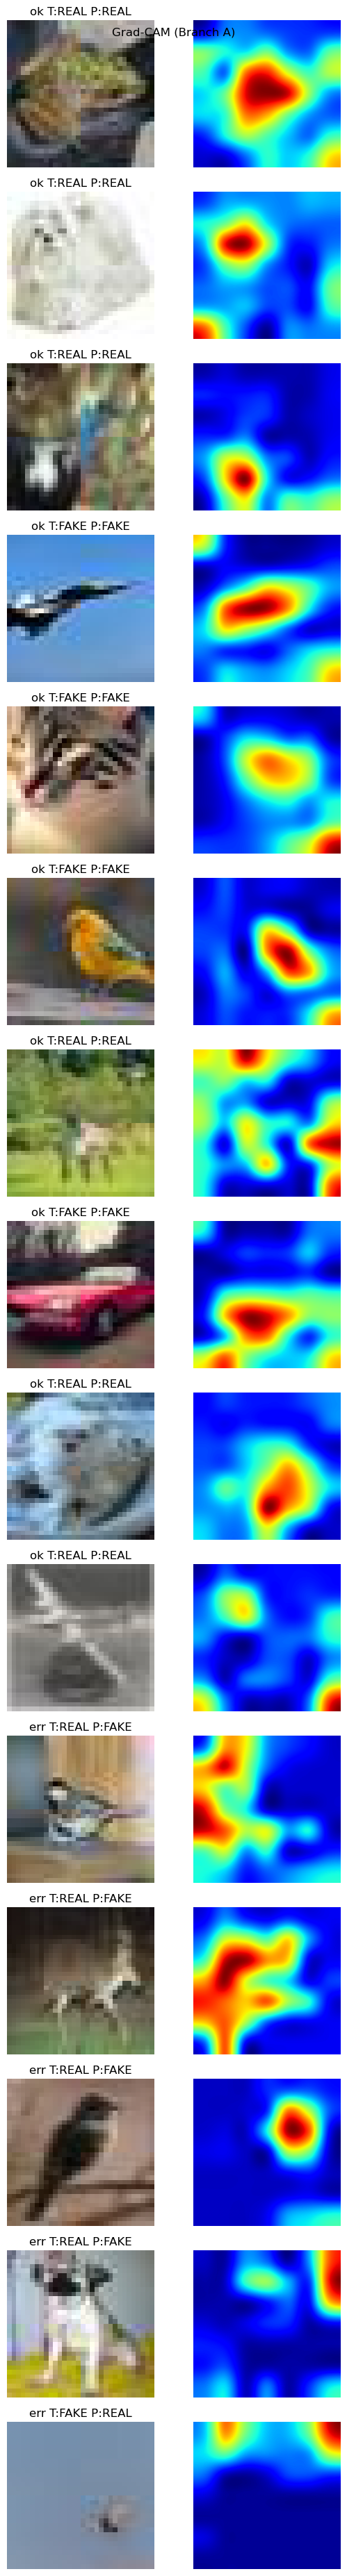

Done. Outputs in outputs/


In [16]:
# Grad-CAM on Branch A (10 correct + 5 wrong samples)
def grad_cam(model, batch, target_class):
    model.eval(); device = next(model.parameters()).device
    spatial = batch["spatial"].to(device).clone().requires_grad_(True)
    freq, noise = batch["frequency"].to(device), batch["noise"].to(device)
    acts, grads = [], []
    h1 = model.spatial.features[-1].register_forward_hook(lambda m,i,o: acts.append(o.detach()))
    h2 = model.spatial.features[-1].register_full_backward_hook(lambda m,i,o: grads.append(o[0].detach()))
    score = model(spatial, freq, noise)["logits"][0, target_class]
    model.zero_grad(set_to_none=True); score.backward(); h1.remove(); h2.remove()
    w = grads[0][0].mean(dim=(1,2))
    cam = torch.relu((w[:,None,None]*acts[0][0]).sum(0)).cpu().numpy()
    cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
    return np.array(Image.fromarray(cam).resize((cfg.img_size,cfg.img_size), Image.BICUBIC))

rng.shuffle(pool)
correct, wrong = [], []
for path, label in pool:
    pred, _ = predict_pil(Image.open(path).convert("RGB"))
    (correct if pred==label else wrong).append((path,label,pred))
    if len(correct)>=10 and len(wrong)>=5: break
picks = [("ok",*c) for c in correct[:10]] + [("err",*w) for w in wrong[:5]]
fig, axes = plt.subplots(len(picks), 2, figsize=(6, 2.5*len(picks)))
for r, (tag, path, label, pred) in enumerate(picks):
    pil = Image.open(path).convert("RGB")
    b = pil_to_batch(pil)
    axes[r,0].imshow(pil); axes[r,0].set_title(f"{tag} T:{cfg.class_names[label]} P:{cfg.class_names[pred]}"); axes[r,0].axis("off")
    axes[r,1].imshow(grad_cam(model, b, pred), cmap="jet"); axes[r,1].axis("off")
plt.suptitle("Grad-CAM (Branch A)"); plt.tight_layout()
plt.savefig(cfg.outputs_dir / "exp5_gradcam.png", dpi=100, bbox_inches="tight"); plt.show()
print("Done. Outputs in outputs/")
